# Analyse Exploratoire — Détection de Fraude Bancaire
**Projet Python — Master M1 : BDAIA**  
**Auteur : Bilal Jellaoui**  
Dataset : Credit Card Fraud Detection (Kaggle) — 284 807 transactions

---
## Objectifs
- Analyser la distribution des features V1–V28 (PCA anonymisées)
- Visualiser histogrammes, heatmap de corrélation
- Calculer statistiques descriptives par classe (fraude / non-fraude)
- Comprendre le déséquilibre de classes (0,17% de fraudes)
- Justifier les choix de prétraitement (SMOTE, StandardScaler)

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Chemin vers le dataset
# Le notebook est dans notebooks/ → on remonte avec ../ vers fraud_detection/
DATA_PATH = Path('../data/creditcard.csv')

# Créer le dossier data/ s'il n'existe pas (ex: après git clone)
Path('../data').mkdir(parents=True, exist_ok=True)

print('✓ Imports OK')
print(f'  Dataset path : {DATA_PATH.resolve()}')
print(f'  Dataset exists : {DATA_PATH.exists()}')

✓ Imports OK
  Dataset path : D:\master cours\Python\Projet python\fraud_detection\data\creditcard.csv
  Dataset exists : True


## 2. Chargement du dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes   : {list(df.columns)}')
print(f'\nTypes de données :')
print(df.dtypes)

print(f'\nMémoire utilisée : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

df.head()

Dimensions : 284,807 lignes × 31 colonnes
Colonnes   : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Types de données :
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Mémoire utilisée : 67.4 MB


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Qualité des données — Valeurs manquantes & doublons

In [3]:
# Valeurs manquantes
missing = df.isnull().sum()
print('=== Valeurs manquantes ===')
if missing.any():
    print(missing[missing > 0])
else:
    print('✓ Aucune valeur manquante')

# Doublons
n_duplicates = df.duplicated().sum()
print(f'\n=== Doublons ===')
print(f'Nombre de doublons : {n_duplicates}')
if n_duplicates > 0:
    print('→ Suppression des doublons recommandée')
else:
    print('✓ Aucun doublon')

# Statistiques globales
print(f'\n=== Statistiques globales (Amount & Time) ===')
display(df[['Amount', 'Time']].describe().round(2))

=== Valeurs manquantes ===
✓ Aucune valeur manquante

=== Doublons ===
Nombre de doublons : 1081
→ Suppression des doublons recommandée

=== Statistiques globales (Amount & Time) ===


,Amount,Time
count,284807.00,284807.00
mean,88.35,94813.86
std,250.12,47488.15
min,0.00,0.00
25%,5.60,54201.50
50%,22.00,84692.00
75%,77.16,139320.50
max,25691.16,172792.00


## 4. Distribution des classes — Déséquilibre
> **Enjeu projet** : gérer le déséquilibre extrême (0,17% de fraudes) avec **SMOTE**

=== Déséquilibre de classes ===
Légitimes  (0) : 284,315  (99.83%)
Fraudes    (1) :     492  (0.1727%)
Ratio          : 1 fraude pour 577 légitimes

→ Déséquilibre EXTRÊME : SMOTE requis dans preprocess.py


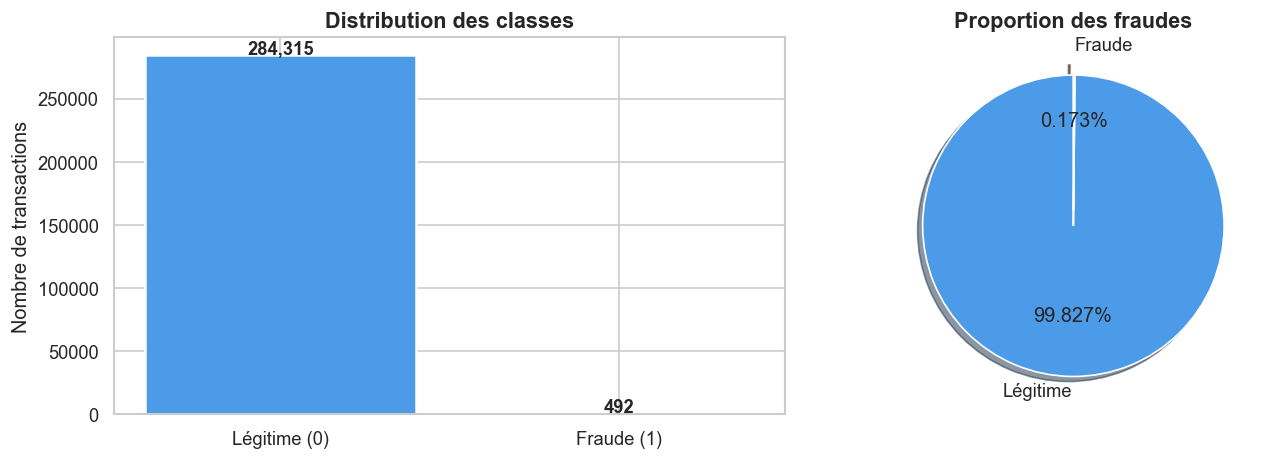

✓ Sauvegardé → data/class_distribution.png


In [4]:
class_counts = df['Class'].value_counts()
fraud_pct    = class_counts[1] / len(df) * 100

print('=== Déséquilibre de classes ===')
print(f'Légitimes  (0) : {class_counts[0]:>7,}  ({100 - fraud_pct:.2f}%)')
print(f'Fraudes    (1) : {class_counts[1]:>7,}  ({fraud_pct:.4f}%)')
print(f'Ratio          : 1 fraude pour {int(class_counts[0] / class_counts[1])} légitimes')
print(f'\n→ Déséquilibre EXTRÊME : SMOTE requis dans preprocess.py')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['Légitime (0)', 'Fraude (1)'],
    [class_counts[0], class_counts[1]],
    color=['#4C9BE8', '#E85D4C'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
for bar, val in zip(bars, [class_counts[0], class_counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1000,
        f'{val:,}', ha='center', fontsize=11, fontweight='bold'
    )

# Pie chart
axes[1].pie(
    [class_counts[0], class_counts[1]],
    labels=['Légitime', 'Fraude'],
    autopct='%1.3f%%',
    colors=['#4C9BE8', '#E85D4C'],
    startangle=90,
    explode=(0, 0.1),
    shadow=True
)
axes[1].set_title('Proportion des fraudes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/class_distribution.png', bbox_inches='tight')
plt.show()
print('✓ Sauvegardé → data/class_distribution.png')

## 5. Distribution du montant (Amount) par classe

C:\Users\Dell\AppData\Local\Temp\ipykernel_14384\3999140203.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


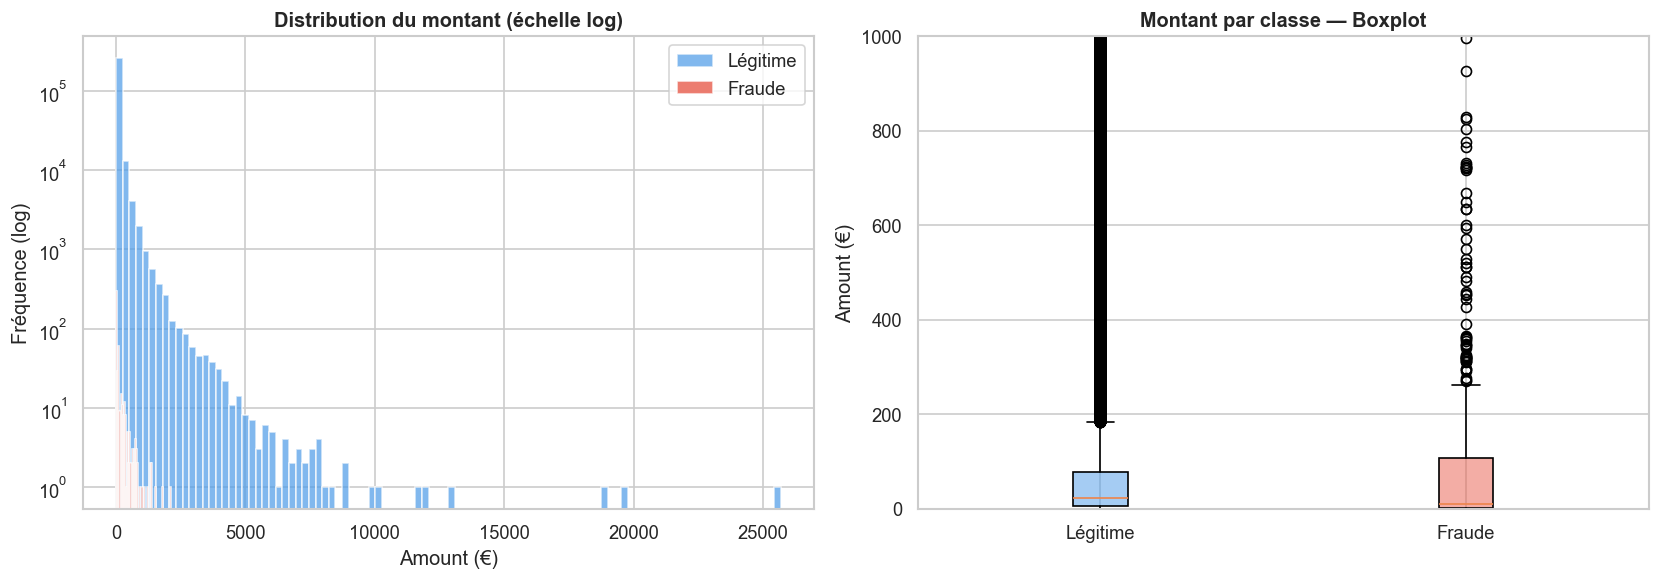

Montant moyen — Légitime : 88.29€
Montant moyen — Fraude   : 122.21€
Montant médian — Fraude  : 9.25€
Montant max   — Fraude   : 2125.87€
✓ Sauvegardé → data/amount_distribution.png


In [5]:
df_fraud = df[df['Class'] == 1]
df_legit = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme Amount (échelle log)
axes[0].hist(df_legit['Amount'], bins=100, color='#4C9BE8',
             alpha=0.7, label='Légitime', log=True)
axes[0].hist(df_fraud['Amount'], bins=50,  color='#E85D4C',
             alpha=0.8, label='Fraude',   log=True)
axes[0].set_title('Distribution du montant (échelle log)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Fréquence (log)')
axes[0].legend()

# Boxplot — notch=False pour éviter erreur sans scipy
bp = axes[1].boxplot(
    [df_legit['Amount'].values, df_fraud['Amount'].values],
    patch_artist=True,
    labels=['Légitime', 'Fraude']
)
bp['boxes'][0].set_facecolor('#4C9BE880')
bp['boxes'][1].set_facecolor('#E85D4C80')
axes[1].set_title('Montant par classe — Boxplot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount (€)')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../data/amount_distribution.png', bbox_inches='tight')
plt.show()

print(f'Montant moyen — Légitime : {df_legit["Amount"].mean():.2f}€')
print(f'Montant moyen — Fraude   : {df_fraud["Amount"].mean():.2f}€')
print(f'Montant médian — Fraude  : {df_fraud["Amount"].median():.2f}€')
print(f'Montant max   — Fraude   : {df_fraud["Amount"].max():.2f}€')
print('✓ Sauvegardé → data/amount_distribution.png')

## 6. Distribution temporelle (Time)

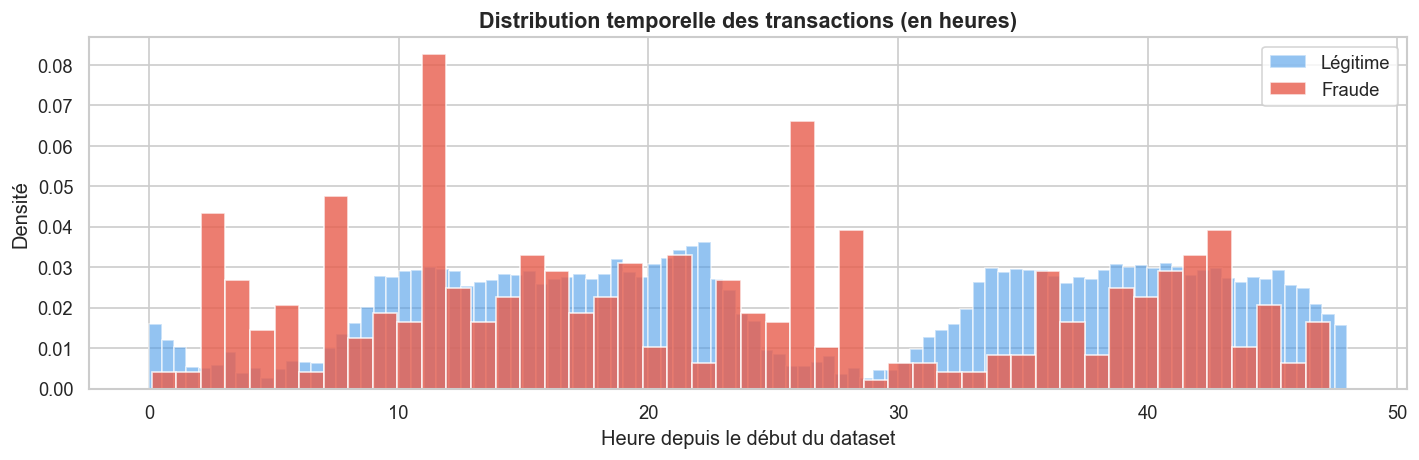

Période couverte : 48.0 heures (~2 jours)
✓ Sauvegardé → data/time_distribution.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(df_legit['Time'] / 3600, bins=96, color='#4C9BE8',
        alpha=0.6, label='Légitime', density=True)
ax.hist(df_fraud['Time'] / 3600, bins=48, color='#E85D4C',
        alpha=0.8, label='Fraude',   density=True)

ax.set_title('Distribution temporelle des transactions (en heures)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Heure depuis le début du dataset')
ax.set_ylabel('Densité')
ax.legend()

plt.tight_layout()
plt.savefig('../data/time_distribution.png', bbox_inches='tight')
plt.show()

print(f'Période couverte : {df["Time"].max() / 3600:.1f} heures (~2 jours)')
print('✓ Sauvegardé → data/time_distribution.png')

## 7. Distribution des features V1–V28 (PCA anonymisées)
> Ces 28 features sont le résultat d'une transformation PCA pour préserver la confidentialité.
> Elles sont **déjà normalisées** → StandardScaler appliqué uniquement sur Amount et Time.

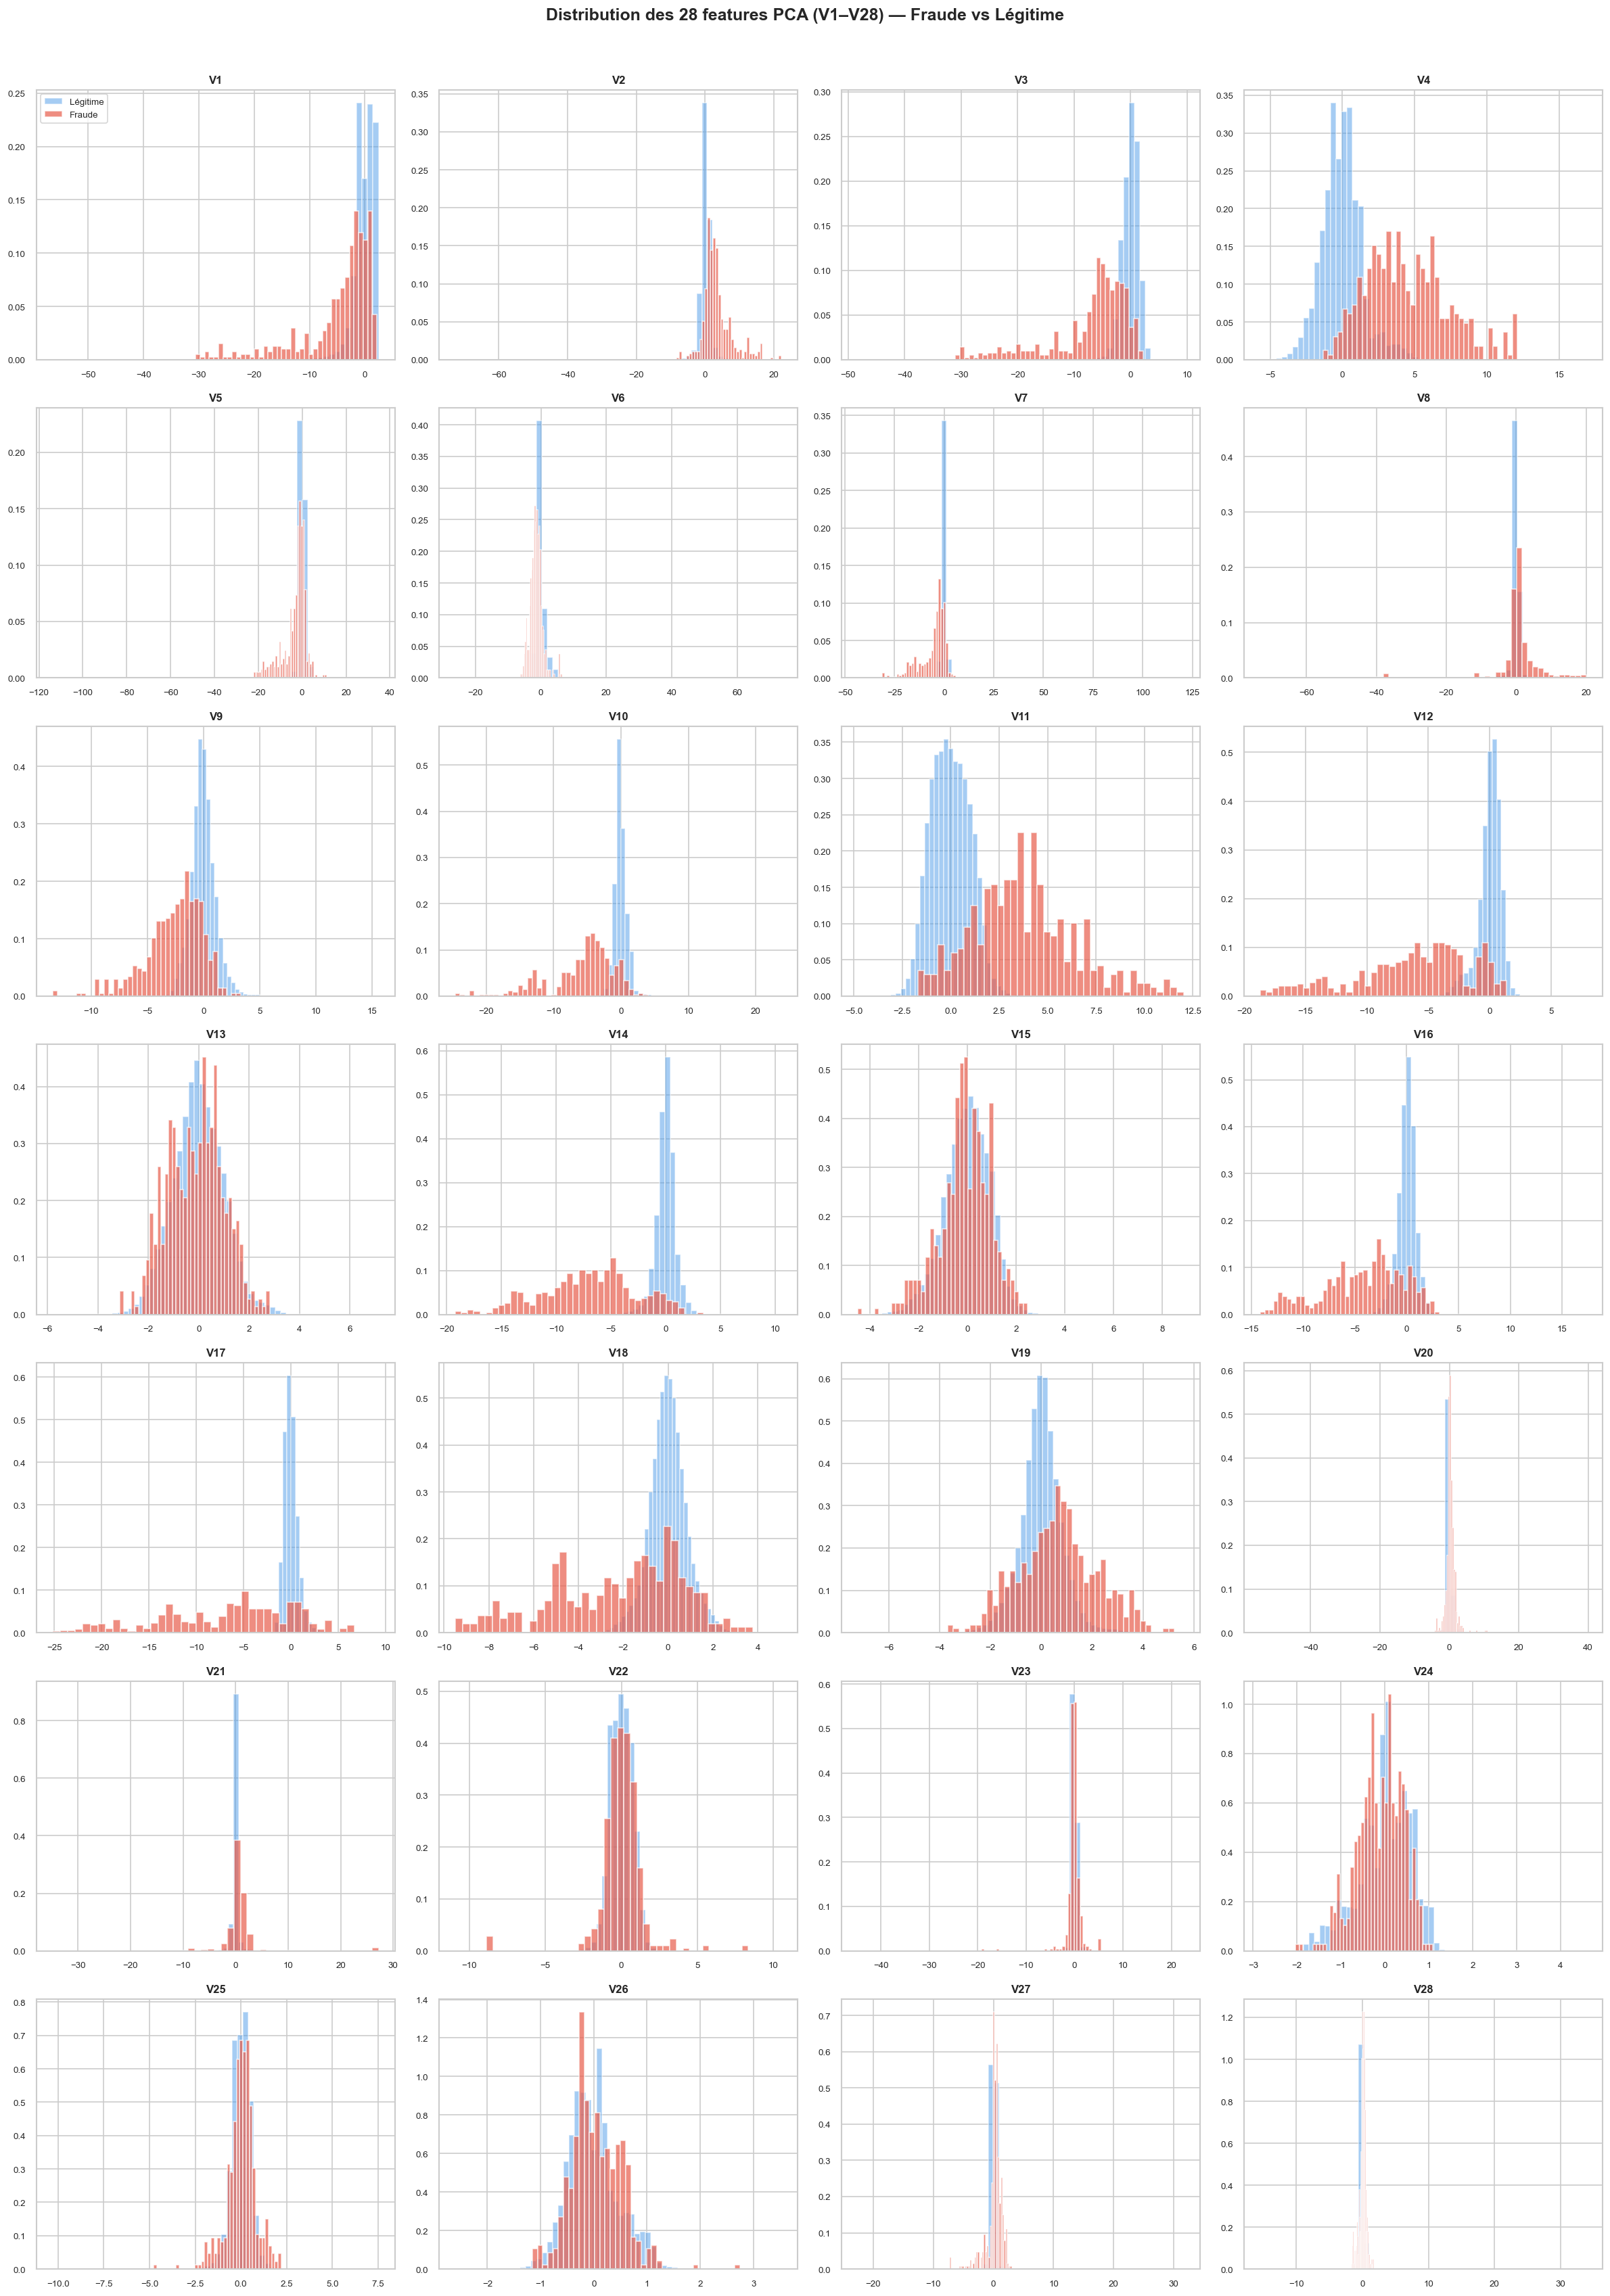

✓ Sauvegardé → data/v_features_distribution.png


In [7]:
features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df_legit[feat], bins=60, color='#4C9BE8',
                 alpha=0.5, label='Légitime', density=True)
    axes[i].hist(df_fraud[feat], bins=40, color='#E85D4C',
                 alpha=0.7, label='Fraude',   density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribution des 28 features PCA (V1–V28) — Fraude vs Légitime',
             y=1.01, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/v_features_distribution.png', bbox_inches='tight')
plt.show()
print('✓ Sauvegardé → data/v_features_distribution.png')

## 8. Statistiques descriptives par classe

=== Statistiques des features par classe ===

--- Features : V1 → V8 ---


V1            V2            V3            V4            V5         \
        mean    std   mean    std   mean    std   mean    std   mean    std   
Class                                                                         
0      0.008  1.930 -0.006  1.636  0.012  1.459 -0.008  1.399  0.005  1.357   
1     -4.772  6.784  3.624  4.291 -7.033  7.111  4.542  2.873 -3.151  5.372   

          V6            V7            V8         
        mean    std   mean    std   mean    std  
Class                                            
0      0.002  1.330  0.010  1.179 -0.001  1.161  
1     -1.398  1.858 -5.569  7.207  0.571  6.798


--- Features : V9 → V16 ---


V9           V10           V11           V12           V13         \
        mean    std   mean    std   mean    std   mean    std   mean    std   
Class                                                                         
0      0.004  1.089  0.010  1.044 -0.007  1.003  0.011  0.946  0.000  0.995   
1     -2.581  2.501 -5.677  4.897  3.800  2.679 -6.259  4.654 -0.109  1.105   

         V14           V15           V16         
        mean    std   mean    std   mean    std  
Class                                            
0      0.012  0.897  0.000  0.915  0.007  0.845  
1     -6.972  4.279 -0.093  1.050 -4.140  3.865


--- Features : V17 → V24 ---


V17           V18           V19           V20           V21         \
        mean    std   mean    std   mean    std   mean    std   mean    std   
Class                                                                         
0      0.012  0.749  0.004  0.825 -0.001  0.812 -0.001  0.769 -0.001  0.717   
1     -6.666  6.971 -2.246  2.899  0.681  1.540  0.372  1.347  0.714  3.869   

         V22          V23           V24         
        mean    std  mean    std   mean    std  
Class                                           
0     -0.000  0.724  0.00  0.622  0.000  0.606  
1      0.014  1.495 -0.04  1.580 -0.105  0.516


--- Features : V25 → Time ---


V25           V26           V27           V28          Amount  \
        mean    std   mean    std   mean    std   mean    std     mean   
Class                                                                    
0     -0.000  0.521 -0.000  0.482 -0.000  0.400 -0.000  0.330   88.291   
1      0.041  0.797  0.052  0.472  0.171  1.377  0.076  0.547  122.211   

                     Time             
           std       mean        std  
Class                                 
0      250.105  94838.202  47484.016  
1      256.683  80746.807  47835.365


=== Top 10 features discriminantes ===
V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749


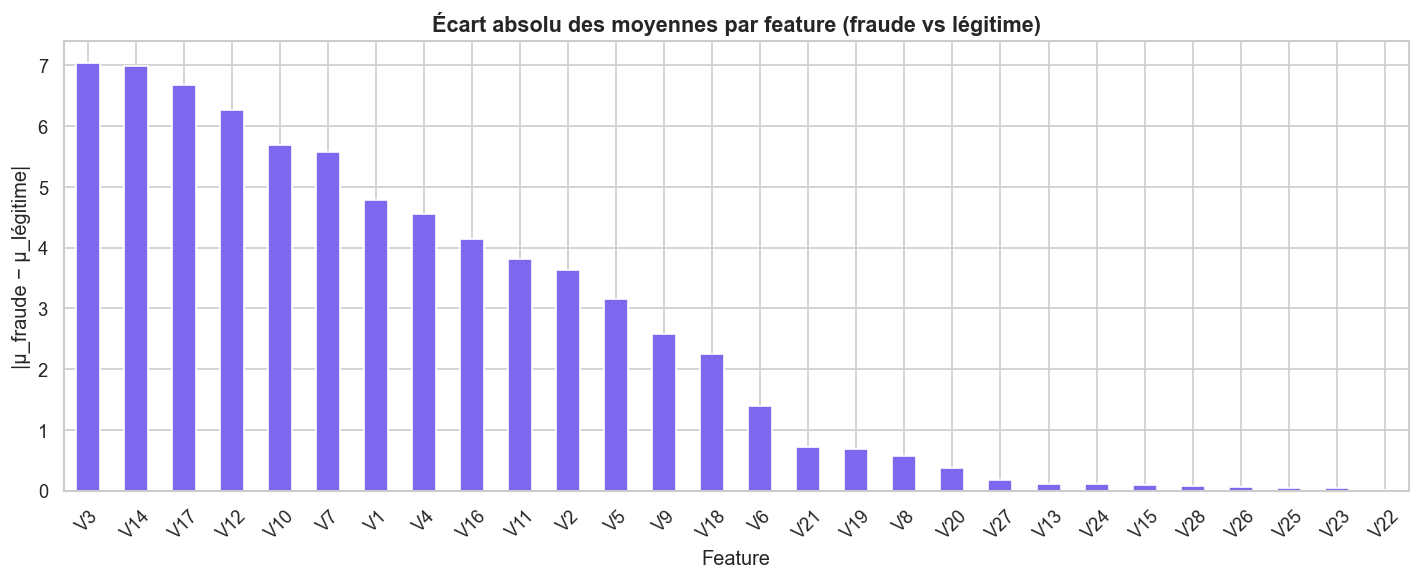

✓ Sauvegardé → data/feature_discrimination.png


In [8]:
print('=== Statistiques des features par classe ===')

all_feats = features + ['Amount', 'Time']
stats = df.groupby('Class')[all_feats].agg(['mean', 'std']).round(3)

# Afficher par groupes de 8 features pour la lisibilité
for i in range(0, len(all_feats), 8):
    chunk = all_feats[i:i+8]
    print(f'\n--- Features : {chunk[0]} → {chunk[-1]} ---')
    display(stats[chunk])

# Top features discriminantes (écart de moyenne fraude vs légitime)
diff_means = abs(df_fraud[features].mean() - df_legit[features].mean())
diff_sorted = diff_means.sort_values(ascending=False)

print('\n=== Top 10 features discriminantes ===')
print(diff_sorted.head(10).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
diff_sorted.plot(kind='bar', ax=ax, color='#7B68EE', edgecolor='white')
ax.set_title('Écart absolu des moyennes par feature (fraude vs légitime)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('|µ_fraude − µ_légitime|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/feature_discrimination.png', bbox_inches='tight')
plt.show()
print('✓ Sauvegardé → data/feature_discrimination.png')

## 9. Heatmap de corrélation
> Objectif projet : visualiser avec seaborn/matplotlib — heatmap de corrélation

Calcul de la matrice de corrélation...


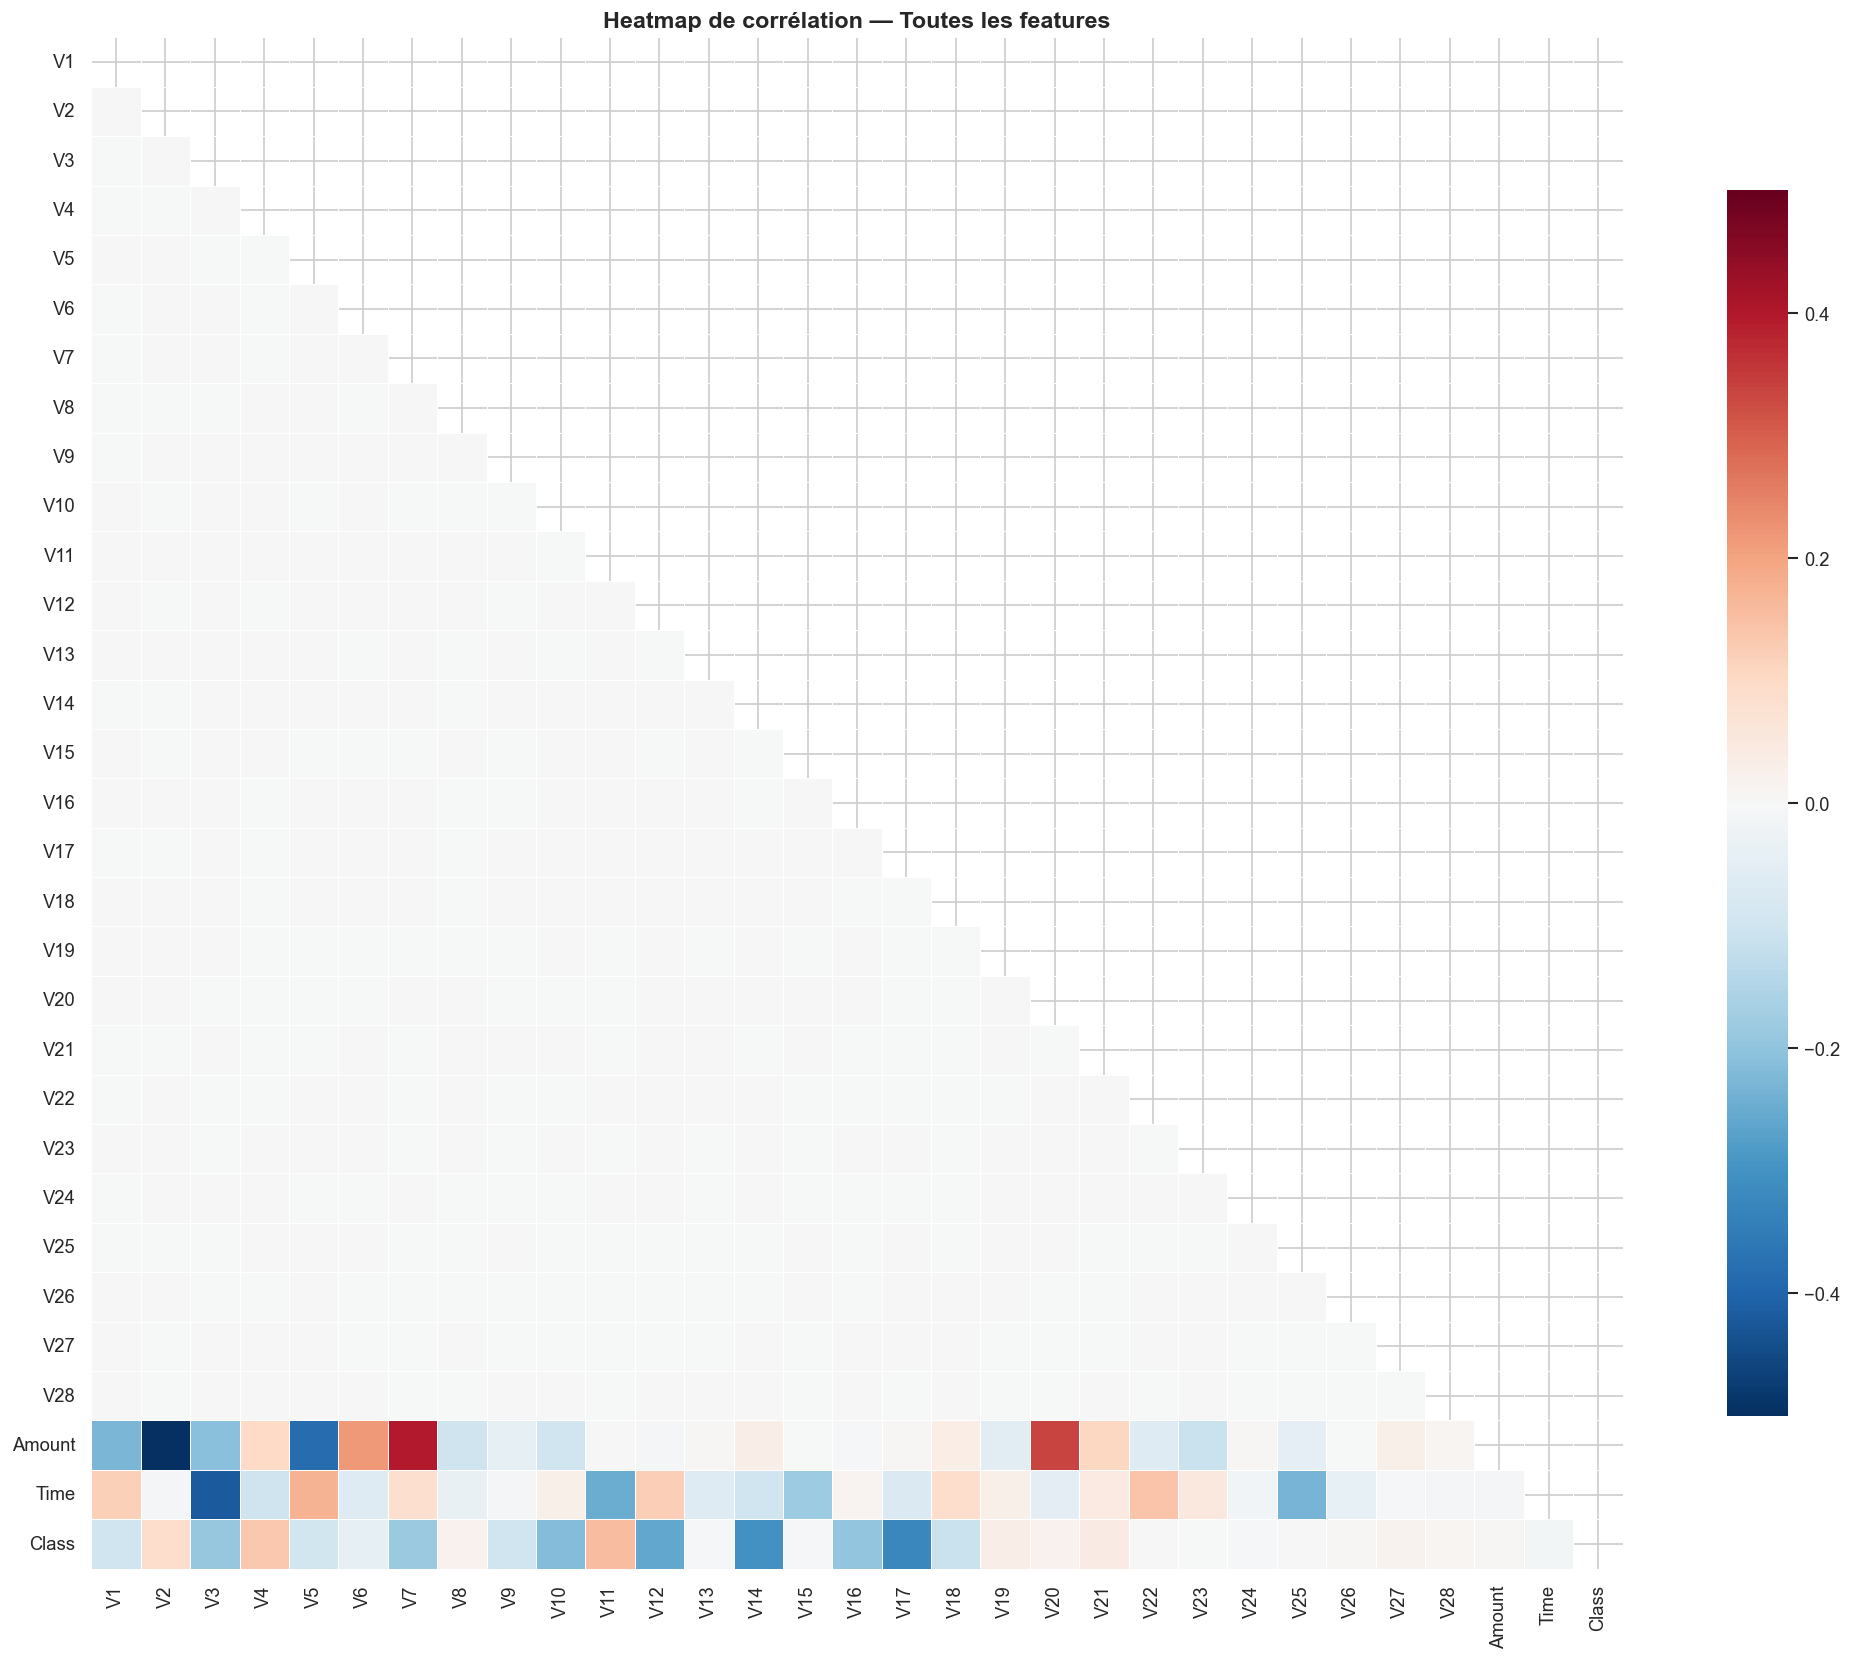

✓ Sauvegardé → data/correlation_heatmap.png

=== Corrélations avec la variable Class ===
V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876


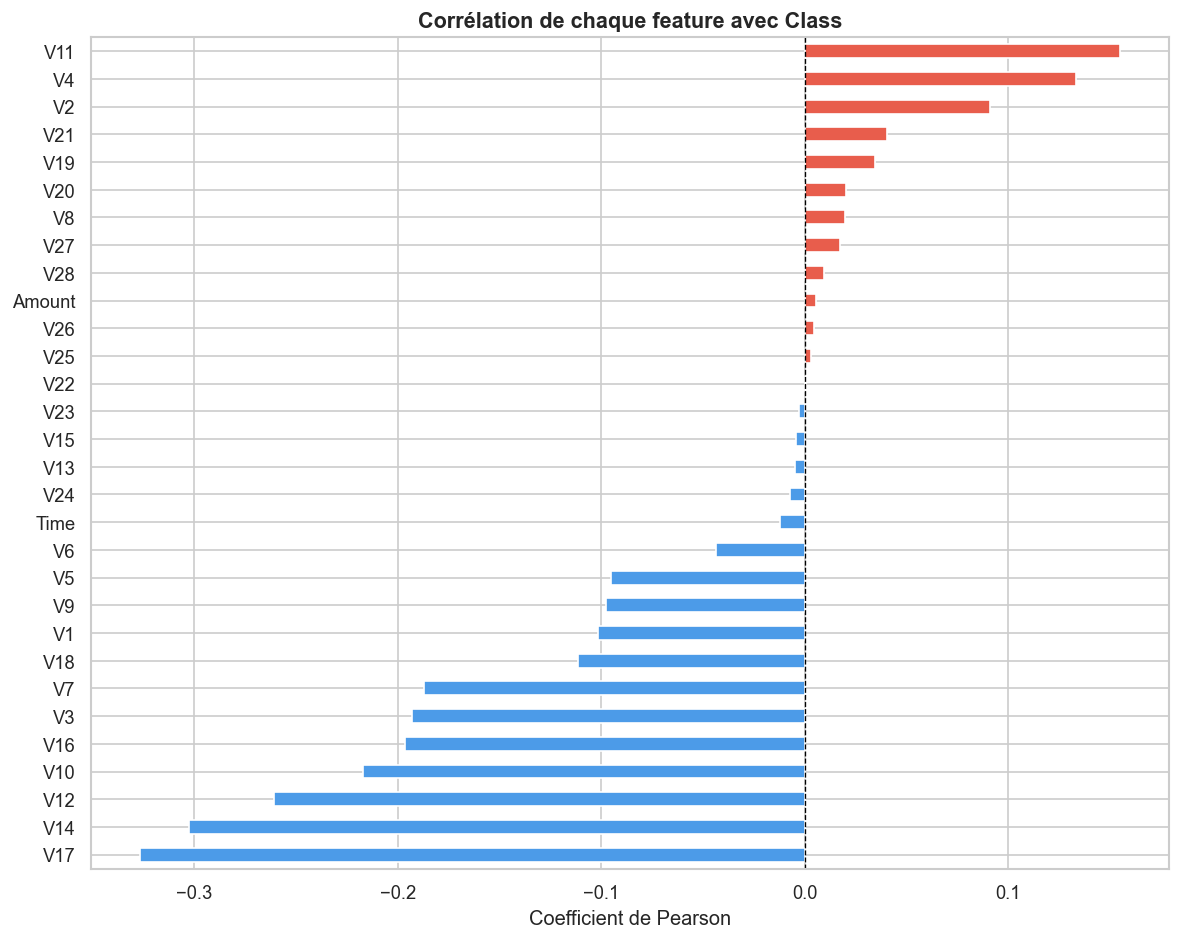

✓ Sauvegardé → data/corr_with_class.png


In [9]:
print('Calcul de la matrice de corrélation...')
corr_matrix = df[features + ['Amount', 'Time', 'Class']].corr()

# Heatmap triangulaire inférieure
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5, vmax=0.5,
    linewidths=0.3,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap de corrélation — Toutes les features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('✓ Sauvegardé → data/correlation_heatmap.png')

# Corrélations avec Class uniquement
corr_class = corr_matrix['Class'].drop('Class').sort_values()
print('\n=== Corrélations avec la variable Class ===')
print(corr_class.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E85D4C' if v > 0 else '#4C9BE8' for v in corr_class]
corr_class.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Corrélation de chaque feature avec Class',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient de Pearson')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/corr_with_class.png', bbox_inches='tight')
plt.show()
print('✓ Sauvegardé → data/corr_with_class.png')

## 10. Résumé EDA — Conclusions et décisions de prétraitement

In [10]:
print('=' * 60)
print('  RÉSUMÉ EDA — Détection de Fraude Bancaire')
print('=' * 60)
print(f'  Total transactions        : {len(df):,}')
print(f'  Transactions légitimes    : {class_counts[0]:,} ({100 - fraud_pct:.2f}%)')
print(f'  Transactions frauduleuses : {class_counts[1]:,} ({fraud_pct:.4f}%)')
print(f'  Ratio déséquilibre        : 1:{int(class_counts[0] / class_counts[1])}')
print(f'  Valeurs manquantes        : Aucune')
print(f'  Doublons                  : {df.duplicated().sum()}')
print(f'  Features PCA              : V1–V28 (déjà normalisées)')
print('-' * 60)
print(f'  Top 5 features discriminantes : {list(diff_sorted.head(5).index)}')
print('-' * 60)
print('  DÉCISIONS DE PRÉTRAITEMENT :')
print('  → SMOTE requis   : déséquilibre extrême (0.17%)')
print('  → StandardScaler : sur Amount et Time uniquement')
print('  → Split          : 80% train / 20% test (stratifié)')
print('  → Modèles        : XGBoost, RF, LR, Isolation Forest')
print('=' * 60)

# Récapitulatif des fichiers générés
print('\n=== FICHIERS GÉNÉRÉS ===')
generated = [
    '../data/class_distribution.png',
    '../data/amount_distribution.png',
    '../data/time_distribution.png',
    '../data/v_features_distribution.png',
    '../data/feature_discrimination.png',
    '../data/correlation_heatmap.png',
    '../data/corr_with_class.png',
]
for f in generated:
    exists = Path(f).exists()
    status = '✓' if exists else '✗'
    print(f'  {status} {f}')

  RÉSUMÉ EDA — Détection de Fraude Bancaire
  Total transactions        : 284,807
  Transactions légitimes    : 284,315 (99.83%)
  Transactions frauduleuses : 492 (0.1727%)
  Ratio déséquilibre        : 1:577
  Valeurs manquantes        : Aucune
  Doublons                  : 1081
  Features PCA              : V1–V28 (déjà normalisées)
------------------------------------------------------------
  Top 5 features discriminantes : ['V3', 'V14', 'V17', 'V12', 'V10']
------------------------------------------------------------
  DÉCISIONS DE PRÉTRAITEMENT :
  → SMOTE requis   : déséquilibre extrême (0.17%)
  → StandardScaler : sur Amount et Time uniquement
  → Split          : 80% train / 20% test (stratifié)
  → Modèles        : XGBoost, RF, LR, Isolation Forest

=== FICHIERS GÉNÉRÉS ===
  ✓ ../data/class_distribution.png
  ✓ ../data/amount_distribution.png
  ✓ ../data/time_distribution.png
  ✓ ../data/v_features_distribution.png
  ✓ ../data/feature_discrimination.png
  ✓ ../data/correlati